# Part 2: ResNet-18 Model Improvement Ablations

This notebook keeps the Part 2 workflow notebook-owned while moving reusable training and result logic into project modules. The regular-training baseline is loaded from Part 1 results; the remaining ablations are trained here.

In [1]:
from pathlib import Path
import importlib
import os
import sys

In [2]:
current = Path.cwd().resolve()
for candidate in [current, *current.parents]:
    if (candidate / 'src').is_dir() and (candidate / 'requirements.txt').exists():
        ROOT = candidate
        break
else:
    ROOT = current

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

In [3]:
def install_project_requirements_for_colab(project_root: Path) -> None:
    """Install non-PyTorch dependencies in Colab without replacing CUDA-matched torch wheels."""
    try:
        import google.colab  # type: ignore  # noqa: F401
    except ImportError:
        return

    import subprocess

    requirements_path = project_root / 'requirements.txt'
    filtered_requirements = Path('/tmp/mlds_colab_requirements.txt')
    skip_prefixes = ('torch', 'torchvision')
    filtered_lines = [
        line
        for line in requirements_path.read_text().splitlines()
        if not line.strip().lower().startswith(skip_prefixes)
    ]
    filtered_requirements.write_text('\n'.join(filtered_lines) + '\n')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-r', str(filtered_requirements)])


In [4]:
install_project_requirements_for_colab(ROOT)

ROOT

PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project')

In [5]:
import pandas as pd
from IPython.core.display import Image
from IPython.display import display

import src.evaluation.experiment_results as experiment_results

experiment_results = importlib.reload(experiment_results)
import src.experiments.part2 as part2_experiments  # noqa: E402
part2_experiments = importlib.reload(part2_experiments)
experiment_output_paths = experiment_results.experiment_output_paths
get_device = experiment_results.get_device
load_part1_model_baseline_aggregated = experiment_results.load_part1_model_baseline_aggregated
run_part2_improvement_experiments = part2_experiments.run_part2_improvement_experiments
from src.utils.config import Part2ExperimentConfig  # noqa: E402
from src.utils.reproducibility import seed_everything  # noqa: E402

/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [6]:
config = Part2ExperimentConfig()
device = get_device(config)
output_paths = experiment_output_paths(config.results_dir, config.figures_dir, config.part)
seed_everything(config.seed, deterministic=config.deterministic)

pd.DataFrame(
    [
        {
            'part': config.part,
            'config_name': config.config_name,
            'model_name': config.model_name,
            'tiles_per_side_values': config.tiles_per_side_values,
            'num_tile_permutations': config.num_tile_permutations,
            'epochs': config.epochs,
            'device': str(device),
        }
    ]
)

Selected device: cpu


,part,config_name,model_name,tiles_per_side_values,num_tile_permutations,epochs,device
0,part2,part2_improvement,resnet18,"[1, 3]",2,1,cpu


In [7]:
pd.DataFrame(config.ablations)

,name,use_pretrained,augmentation,curriculum
0,random_erasing_only,True,random_erasing,NaN
1,same_label_cutmix_only,True,same_label_cutmix,NaN
2,patch_shuffle_only,True,patch_shuffle,NaN
3,combined_corruptions,True,combined_corruptions,NaN
4,permutation_difficulty_curriculum,True,none,permutation_difficulty
5,corruption_probability_curriculum,True,none,corruption_probability


## Part 1 ResNet-18 Baseline

In [8]:
part1_baseline_aggregated = load_part1_model_baseline_aggregated(config, config.model_name)
if not part1_baseline_aggregated.empty:
    display(part1_baseline_aggregated)

,model_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs,ablation_name,config_name
0,resnet18,3.0,9,0.894231,0.013598,0.894231,0.013598,2,regular_part1,part2_improvement
1,resnet18,NaN,1,0.865385,NaN,0.903846,NaN,1,regular_part1,part2_improvement


## Train Improvement Ablations

In [9]:
RUN_TRAINING = True

if RUN_TRAINING:
    part2_results = run_part2_improvement_experiments(config=config, device=device)
    display(part2_results)
else:
    print('Training is skipped. Set RUN_TRAINING = True to train Part 2 ablations in this notebook.')

Raw results path: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part2_raw_results.csv
Checkpoint directory: /Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/checkpoints/part2/part2_20260513_064437
Saved 18 pending row(s) for model 'resnet18'.

Running ablation: random_erasing_only

[1/3] model=resnet18, ablation=random_erasing_only, tiles_per_side=None, tile_permutation_id=0, seed=42, stages=1 [standard: 1 epoch]
Building dataloaders...
Built dataloaders: train=204 samples / 13 batches, validation=52 samples / 4 batches.
Building model 'resnet18'...


resnet18 random_erasing_only 1x1 permutation 0: 100%|██████████| 1/1 [01:23<00:00, 83.89s/epoch, best_val_accuracy=0.942, stage=standard, train_accuracy=0.828, train_loss=0.367, val_accuracy=0.942, val_loss=0.162]


Current run runtime: 1m 02s
Total training runtime: 1m 02s

[2/3] model=resnet18, ablation=random_erasing_only, tiles_per_side=3, tile_permutation_id=1, seed=42, stages=1 [standard: 1 epoch]
Building dataloaders...
Built dataloaders: train=204 samples / 13 batches, validation=52 samples / 4 batches.
Building model 'resnet18'...


resnet18 random_erasing_only 3x3 permutation 1: 100%|██████████| 1/1 [00:46<00:00, 46.40s/epoch, best_val_accuracy=0.904, stage=standard, train_accuracy=0.784, train_loss=0.456, val_accuracy=0.904, val_loss=0.394]


Current run runtime: 47s
Total training runtime: 2m 08s

[3/3] model=resnet18, ablation=random_erasing_only, tiles_per_side=3, tile_permutation_id=2, seed=42, stages=1 [standard: 1 epoch]
Building dataloaders...
Built dataloaders: train=204 samples / 13 batches, validation=52 samples / 4 batches.
Building model 'resnet18'...


...

Current run runtime: 1m 08s
Total training runtime: 15m 31s

[3/3] model=resnet18, ablation=combined_corruptions, tiles_per_side=3, tile_permutation_id=2, seed=42, stages=1 [standard: 1 epoch]
Building dataloaders...
Built dataloaders: train=204 samples / 13 batches, validation=52 samples / 4 batches.
Building model 'resnet18'...


resnet18 combined_corruptions 3x3 permutation 2: 100%|██████████| 1/1 [00:58<00:00, 58.57s/epoch, best_val_accuracy=0.923, stage=standard, train_accuracy=0.799, train_loss=0.469, val_accuracy=0.923, val_loss=0.3]


Current run runtime: 59s
Total training runtime: 16m 50s

Running ablation: permutation_difficulty_curriculum

[1/3] model=resnet18, ablation=permutation_difficulty_curriculum, tiles_per_side=None, tile_permutation_id=0, seed=42, stages=1 [original: 1 epoch]
Building dataloaders...
Built dataloaders: train=204 samples / 13 batches, validation=52 samples / 4 batches.
Stage dataloaders: original=204 samples / 13 batches.
Building model 'resnet18'...


resnet18 permutation_difficulty_curriculum 1x1 permutation 0:   0%|          | 0/1 [04:07<?, ?epoch/s]


OSError: [Errno 28] No space left on device: '/Users/royrubin/Documents/GitHub/MLDS_Final_Project/outputs/results/part2_raw_results.csv'

## Results

In [ ]:
results_path = Path(output_paths['aggregated_results'])

if results_path.exists():
    part2_results = pd.read_csv(results_path)
    if 'regular_part1' not in set(part2_results.get('ablation_name', [])) and not part1_baseline_aggregated.empty:
        part2_results = pd.concat([part1_baseline_aggregated, part2_results], ignore_index=True, sort=False)
    display(part2_results.sort_values(['tiles_per_side', 'ablation_name']))
else:
    print('Part 2 aggregated results were not found. Set RUN_TRAINING = True and run the training cell.')
    if part1_baseline_aggregated.empty:
        print('Part 1 ResNet-18 baseline results were also not found; run Part 1 first to include regular_part1.')

,model_name,ablation_name,tiles_per_side,num_tiles,mean_final_epoch_val_accuracy,std_final_epoch_val_accuracy,mean_best_epoch_val_accuracy,std_best_epoch_val_accuracy,n_runs
0,resnet18,combined_corruptions,3.0,9,0.855769,0.095187,0.855769,0.095187,2
2,resnet18,corruption_probability_curriculum,3.0,9,0.836538,0.013598,0.846154,0.000000,2
4,resnet18,patch_shuffle_only,3.0,9,0.836538,0.013598,0.836538,0.013598,2
6,resnet18,permutation_difficulty_curriculum,3.0,9,0.894231,0.095187,0.894231,0.095187,2
8,resnet18,random_erasing_only,3.0,9,0.855769,0.067991,0.855769,0.067991,2
10,resnet18,regular_part1,3.0,9,0.894231,0.013598,0.894231,0.013598,2
12,resnet18,same_label_cutmix_only,3.0,9,0.855769,0.013598,0.855769,0.013598,2
1,resnet18,combined_corruptions,NaN,1,0.923077,NaN,0.923077,NaN,1
3,resnet18,corruption_probability_curriculum,NaN,1,0.942308,NaN,0.980769,NaN,1
5,resnet18,patch_shuffle_only,NaN,1,0.903846,NaN,0.903846,NaN,1


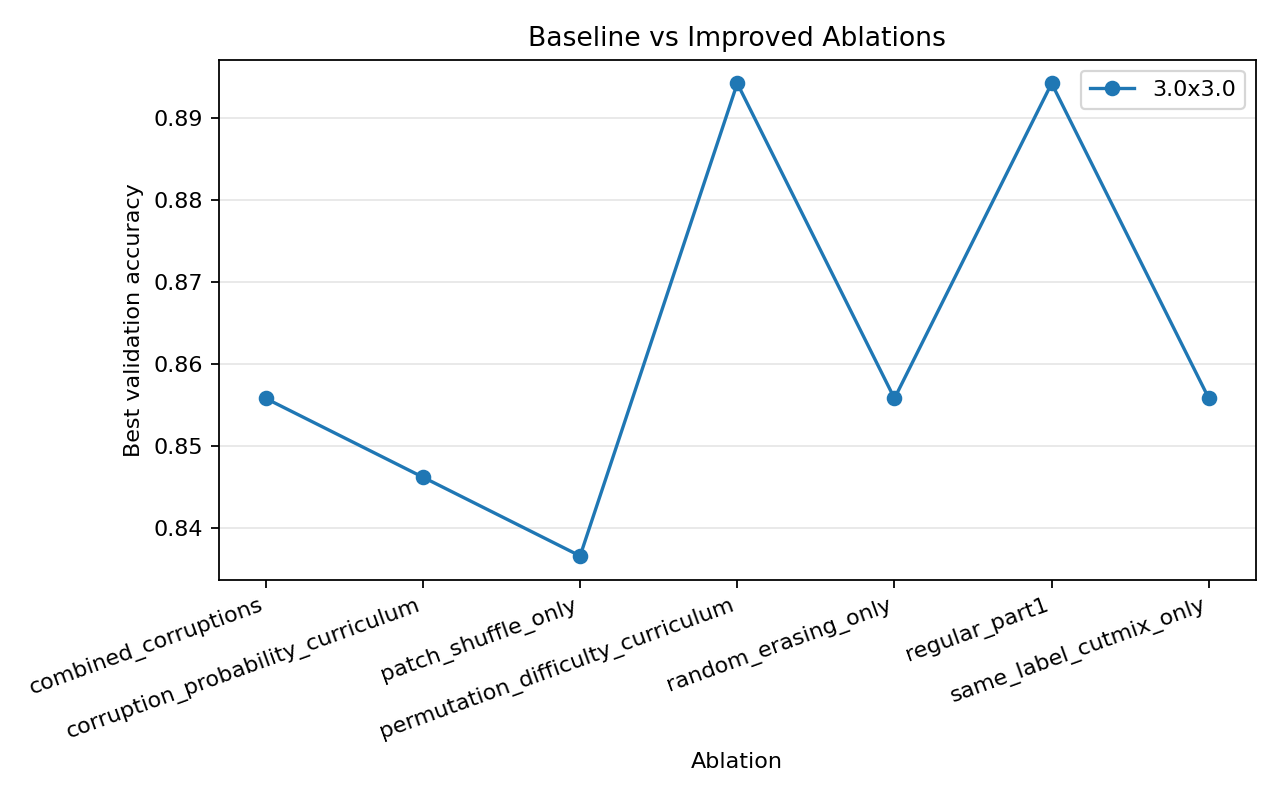

In [ ]:
figure_path = Path(output_paths['figure'])
if figure_path.exists():
    display(Image(filename=str(figure_path)))
else:
    print('Part 2 ablation figure has not been generated yet.')